In [2]:
import os
import json
import pandas as pd

In [4]:
if "moved_up_dir" not in globals():
    # Code that should run once
    %cd ..
    moved_up_dir = True
else:
    print("Skipping — already executed this session.")

/home/woodbkb2/git/nepo-music


In [7]:
nodes_df = pd.read_csv('data/graphs/only_connected/nodes.csv')

In [8]:
edges_df = pd.read_csv('data/graphs/only_connected/edges.csv')

In [9]:
features_df = pd.read_csv('data/artist_base_features_5_years_only_collab.csv')

In [10]:
nodes_df.shape, edges_df.shape, features_df.shape

((86762, 40), (1426829, 3), (86762, 40))

In [11]:
df_sorted = features_df.sort_values(by="unique_collaborator_count", ascending=False)
df_sorted.head()

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,primary_genre,all_genres_str,artist_country,artist_region_city,years_active,debut_year,debut_decade,recency_index,primary_role,all_roles_str
18397,2873b450-13c6-4ca1-8ca3-646c25af3202,NLE Choppa,5,2018-02-28,2023-02-28,156,31.204272,11.664516,0.089453,32.672723,...,NaN,NaN,United States,Memphis,7.759069,2018,2010,0.441312,composer,"composer, lyricist, phonographic copyright, pr..."
84075,587e775d-5798-41bb-b039-c6af5095e1c4,Amadea Music Productions,5,2019-07-23,2024-07-23,182,36.385057,9.491713,0.119459,43.632370,...,NaN,NaN,United Kingdom,NaN,6.362765,2019,2010,0.136586,unknown,NaN
34653,76716b81-e361-427e-a931-19373388387d,Mase,5,1996-01-01,2001-01-01,303,60.575123,6.006623,0.230414,84.158673,...,hip hop,"hip hop, r&b, soul, rap",Atlanta,Jacksonville,29.919233,1996,1990,0.643901,composer,"composer, lyricist, performer, producer, vocal..."
26588,c0367e31-dc3a-4f5e-9d24-0e3af39a8704,Louis Bell,5,2016-01-01,2021-01-01,1072,214.311987,1.690943,0.764438,279.210807,...,pop,"pop, ballad, contemporary r&b, dance-pop, elec...",United States,Quincy,9.919233,2016,2010,0.766365,composer,"composer, editor, engineer, instrument, lyrici..."
53757,2f3c4d70-0462-40da-bba3-0aec5772c556,Cardi B,5,2016-01-01,2021-01-01,444,88.763547,4.108352,0.330173,120.595642,...,hip hop,"hip hop, trap, ballad, r&b, soul, meme, danceh...",United States,The Bronx,9.919233,2016,2010,0.799803,composer,"composer, lyricist, performer, vocal, writer"


In [12]:
nodes_df[nodes_df['artist_name'] == 'Taylor Swift']

,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,primary_genre,all_genres_str,artist_country,artist_region_city,years_active,debut_year,debut_decade,recency_index,primary_role,all_roles_str
27704,20244d07-534f-4eff-b4d4-930878889970,Taylor Swift,5,1928-01-01,1933-01-01,1,0.199918,NaN,NaN,NaN,...,ambient,"ambient, celtic, christmas, christmas carol, c...",United States,West Reading,97.919233,1928,1920,1.0,composer,"composer, editor, instrument, lyricist, perfor..."


In [13]:
edges_df.shape

(1426829, 3)

In [14]:
unique_mbids = set(edges_df["u"]).union(edges_df["v"])
known_mbids = set(features_df["artist_mbid"])
missing_mbids = unique_mbids - known_mbids

len(unique_mbids), len(known_mbids), len(missing_mbids)

(243233, 86762, 156471)

In [15]:
missing_to_template = {}

for row in edges_df.itertuples(index=False):
    u = row.u
    v = row.v

    # If u is missing but v is known, we can use v as template for u
    if u in missing_mbids and v in known_mbids and u not in missing_to_template:
        missing_to_template[u] = v

    # If v is missing but u is known, we can use u as template for v
    if v in missing_mbids and u in known_mbids and v not in missing_to_template:
        missing_to_template[v] = u

print(f"Can assign templates for {len(missing_to_template)} of {len(missing_mbids)} missing mbids.")

# 4) Build synthetic rows by copying the template rows
missing_with_template = [
    m for m in missing_mbids
    if m in missing_to_template
]

if missing_with_template:
    # 2) Get the corresponding template mbids
    template_mbids = [missing_to_template[m] for m in missing_with_template]

    # 3) Index features_df by artist_mbid once
    features_idx = features_df.set_index("artist_mbid")

    # Keep only templates that actually exist in features_df
    mask_existing = [t in features_idx.index for t in template_mbids]
    missing_with_template = [m for m, ok in zip(missing_with_template, mask_existing) if ok]
    template_mbids = [t for t, ok in zip(template_mbids, mask_existing) if ok]

    if template_mbids:
        # 4) Grab all template rows in one shot, preserving order
        base_rows = features_idx.loc[template_mbids].reset_index()

        # 5) Overwrite identifiers / fields vectorized
        base_rows["artist_mbid"] = missing_with_template          # new IDs
        base_rows["mbid_mbid"] = missing_with_template            # your custom field
        base_rows["artist_name"] = "unknown"                      # same value for all

        # 6) Append and de-duplicate on artist_mbid
        new_features_df = base_rows
        nodes_df = (
            pd.concat([features_df, new_features_df], ignore_index=True)
              .drop_duplicates(subset=["artist_mbid"], keep="first")
              .reset_index(drop=True)
        )

        print(
            f"Added {len(new_features_df)} synthetic feature rows. "
            f"features_df now has {len(nodes_df)} rows."
        )
    else:
        nodes_df = features_df.copy()
        print("No synthetic rows created; no missing mbids had valid templates in features_df.")
else:
    nodes_df = features_df.copy()
    print("No synthetic rows created; no missing mbids had known neighbors.")

Can assign templates for 156471 of 156471 missing mbids.
Added 156471 synthetic feature rows. features_df now has 243233 rows.


In [16]:
nodes_df = nodes_df.drop(columns=['mbid_mbid'])

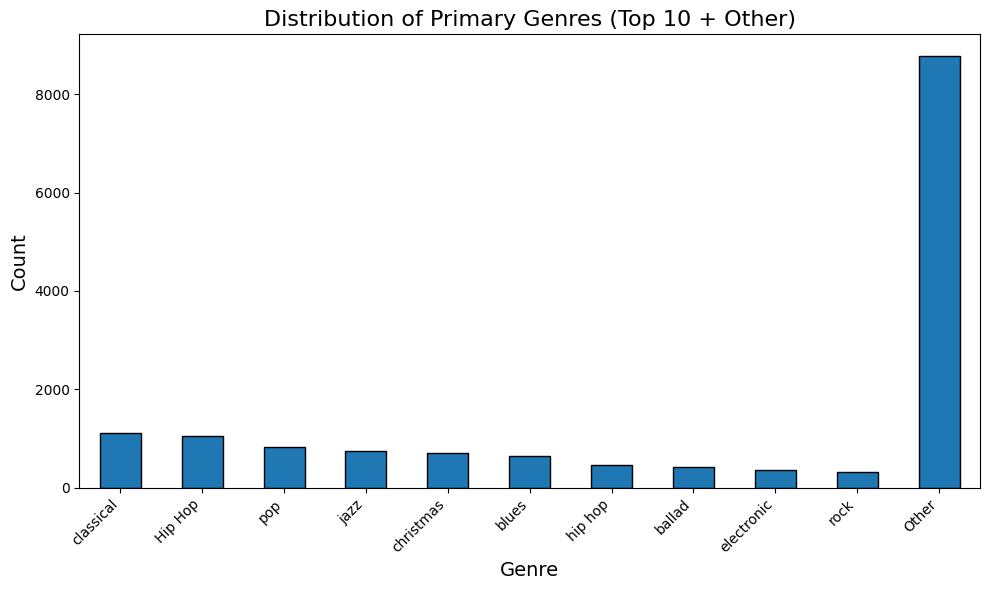

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

genre_series = features_df['primary_genre'].dropna().copy()

# Define subgenres you want to treat as "Hip Hop"
hiphop_aliases = ['boom bap', 'trap', 'drill']

genre_series = genre_series.replace({alias: 'Hip Hop' for alias in hiphop_aliases})


# Count occurrences
genre_counts = genre_series.value_counts()

# Top 10 genres
top10 = genre_counts.head(10)

# Everything else collapsed into "Other"
other_count = genre_counts.iloc[10:].sum()

# Combine using concat (append is removed)
plot_counts = pd.concat([top10, pd.Series({'Other': other_count})])

# Plot
plt.figure(figsize=(10, 6))
plot_counts.plot(kind='bar', edgecolor='black')

plt.title("Distribution of Primary Genres (Top 10 + Other)", fontsize=16)
plt.xlabel("Genre", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [13]:
nodes_df.shape

(243233, 40)

In [14]:
features_df.shape

(86762, 40)

In [39]:
nodes_df.to_csv('data/graphs/only_connected/nodes.csv')

In [42]:
edges_df.to_csv('data/graphs/only_connected/edges.csv')

In [41]:
unique_mbids = set(edges_df["u"]).union(edges_df["v"])
known_mbids = set(nodes_df["artist_mbid"])
missing_mbids = unique_mbids - known_mbids

len(unique_mbids), len(known_mbids), len(missing_mbids)

(243233, 243233, 0)

In [21]:
features_df.columns

Index(['artist_mbid', 'artist_name', 'window_years', 'debut_date',
       'window_cutoff_date', 'releases_total', 'releases_per_year',
       'avg_days_between_releases', 'release_velocity_releases_per_day',
       'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
       'max_dry_spell_days', 'front_loading_index', 'tracks_total',
       'collab_track_rate', 'unique_collaborator_count',
       'label_diversity_count', 'label_churn', 'label_hhi', 'primary_label',
       'all_labels_str', 'duration_ms_mean', 'duration_ms_median',
       'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate',
       'genre_count', 'genre_entropy', 'primary_genre', 'all_genres_str',
       'artist_country', 'artist_region_city', 'years_active', 'debut_year',
       'debut_decade', 'recency_index', 'primary_role', 'all_roles_str'],
      dtype='object')

In [15]:
enriched_nodes = features_df[features_df['artist_mbid'].isin(unique_mbids)]
enriched_nodes.shape

(86762, 40)

In [52]:
enriched_nodes.to_csv('data/graphs/only_connected/enriched_nodes.csv')

In [51]:
edges_df.weight.value_counts()

weight
1      18243
2       5240
3       3657
4       2410
5       1239
       ...  
186        1
222        1
127        1
79         1
74         1
Name: count, Length: 187, dtype: int64

In [6]:
edges_df.columns

Index(['u', 'v', 'weight_raw', 'weight_size_adj', 'first_collab_date',
       'last_collab_date', 'collab_span_years', 'recency_weight',
       'same_primary_genre', 'same_country', 'same_region_city',
       'same_primary_label', 'roles_overlap', 'genres_overlap',
       'labels_overlap', 'mean_team_size_cowrite_joint'],
      dtype='object')

In [7]:
with open('data/artist_collab_data/top_1000_artist_data_full.json') as f:
    data = json.load(f)

In [8]:
def filter_to_n_songs(artists, n=5):
    for artist in artists:
        artist['works'] = artist['works'][:n]
    return artists
filtered_artists = filter_to_n_songs(data)

In [15]:
nodes_df.columns

Index(['artist_mbid', 'artist_name', 'window_years', 'debut_date',
       'window_cutoff_date', 'releases_total', 'releases_per_year',
       'avg_days_between_releases', 'release_velocity_releases_per_day',
       'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
       'max_dry_spell_days', 'front_loading_index', 'tracks_total',
       'collab_track_rate', 'unique_collaborator_count',
       'label_diversity_count', 'label_churn', 'label_hhi', 'primary_label',
       'all_labels_str', 'duration_ms_mean', 'duration_ms_median',
       'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate',
       'genre_count', 'genre_entropy', 'primary_genre', 'all_genres_str',
       'artist_country', 'artist_region_city', 'years_active', 'debut_year',
       'debut_decade', 'recency_index', 'primary_role', 'all_roles_str',
       'missing_recordings_flag', 'missing_genres_flag', 'missing_labels_flag',
       'missing_releases_flag', 'recency_index_missing_flag',
 

In [9]:
data[0]

{'mbid': 'c8b03190-306c-4120-bb0b-6f2ebfc06ea9',
 'artist_name': 'The Weeknd',
 'roles': 'arranger, composer, instrument, lyricist, performer, producer, programming, remixer, vocal, writer',
 'aliases': [],
 'country': 'Canada',
 'region_city': 'Scarborough',
 'works': [{'id': 420723,
   'name': 'Take On Me',
   'release_date': '1984-01-01',
   'genres': ['pop'],
   'collaborators': [{'mbid': '1ac73985-2cfa-433a-a6f8-379480e87179',
     'name': 'Magne Furuholmen',
     'roles': ['writer']},
    {'mbid': '2093207d-cb69-4789-866b-5ac772c9ebd3',
     'name': 'Morten Harket',
     'roles': ['writer']},
    {'mbid': '0ef9b4c4-4a41-4ad8-9c64-98c0419c0150',
     'name': 'Paul Waaktaar-Savoy',
     'roles': ['writer']}]},
  {'id': 441573,
   'name': 'Dirty Diana',
   'release_date': '1987-01-01',
   'genres': [],
   'collaborators': [{'mbid': 'f27ec8db-af05-4f36-916e-3d57f91ecf5e',
     'name': 'Michael Jackson',
     'roles': ['composer', 'lyricist']}]},
  {'id': 12631624,
   'name': 'High fo

In [10]:
import network_construction.graph_builder as gb
from importlib import reload
reload(gb)

<module 'network_construction.graph_builder' from '/home/woodbkb2/git/nepo-music/network_construction/graph_builder.py'>

In [13]:
nodes.columns

Index(['mbid', 'name', 'all_roles', 'all_genres',
       'first_release_date_in_window', 'last_release_date_in_window',
       'num_songs_in_window', 'num_collaborators_in_window',
       'time_in_network_years'],
      dtype='object')

In [14]:
edges.columns

Index(['u', 'v', 'weight_raw', 'weight_size_adj', 'first_collab_date',
       'last_collab_date', 'recency_weight', 'roles_overlap', 'genre_overlap'],
      dtype='object')

In [15]:
artist_song.columns

Index(['artist_mbid', 'artist_name', 'song_id', 'song_name', 'credit_role',
       'release_date', 'genre_tags', 'team_size', 'team_size_cowrite'],
      dtype='object')

In [16]:
nodes.shape

(2806, 9)

In [17]:
with open('data/from_1000_expanded_mbids.txt', 'w') as f:
    for mbid in nodes['mbid'].tolist():
        f.write(f'{mbid}\n')

In [18]:
import pandas as pd
import numpy as np

In [19]:
# cast dates
nodes['first_release_date_in_window'] = pd.to_datetime(nodes['first_release_date_in_window'])
nodes['last_release_date_in_window'] = pd.to_datetime(nodes['last_release_date_in_window'])
edges['first_collab_date'] = pd.to_datetime(edges['first_collab_date'])
edges['last_collab_date'] = pd.to_datetime(edges['last_collab_date'])
artist_song['release_date'] = pd.to_datetime(artist_song['release_date'])

# fill nulls
nodes['all_genres'] = nodes['all_genres'].fillna('')
nodes['all_roles'] = nodes['all_roles'].fillna('')

# ensure IDs are strings
nodes['mbid'] = nodes['mbid'].astype(str)
edges['u'] = edges['u'].astype(str)
edges['v'] = edges['v'].astype(str)

# drop self loops and duplicates
edges = edges.loc[edges['u'] != edges['v']].drop_duplicates(subset=['u','v'])

In [20]:
import re

In [23]:

# make sure string columns are strings (no lists/objects)
for col in ['mbid', 'name', 'all_roles', 'all_genres']:
    nodes[col] = nodes.get(col, "").astype(str).fillna("").replace("nan","")

# clean dates to ISO strings (R will parse as Date easily)
date_cols_nodes = ['first_release_date_in_window','last_release_date_in_window']
for c in date_cols_nodes:
    nodes[c] = pd.to_datetime(nodes[c], errors='coerce').dt.strftime('%Y-%m-%d')

date_cols_edges = ['first_collab_date','last_collab_date']
for c in date_cols_edges:
    edges[c] = pd.to_datetime(edges[c], errors='coerce').dt.strftime('%Y-%m-%d')

# ----- role_major from all_roles (single scalar string) -----
role_patterns = {
    'writer'     : r'(writer|composer|lyricist|librettist|scriptwriter)',
    'performer'  : r'(singer|performer|vocal|artist)',
    'production' : r'(producer|engineer)',
}

def map_role_major(role_text: str) -> str:
    rt = role_text.lower()
    if rt.strip() == "" or rt == "nan":
        return ""
    if re.search(role_patterns['writer'], rt): return "writer"
    if re.search(role_patterns['performer'], rt): return "performer"
    if re.search(role_patterns['production'], rt): return "production"
    return "other"

nodes['role_major'] = nodes['all_roles'].map(map_role_major).astype(str)

# ----- primary_genre from all_genres (first non-empty token) -----
def first_token(gen_text: str) -> str:
    if not isinstance(gen_text, str): return ""
    # split on commas or semicolons or pipes
    toks = [t.strip() for t in re.split(r'[,\|;]', gen_text) if t.strip()]
    return toks[0].lower() if toks else ""

nodes['primary_genre'] = nodes['all_genres'].map(first_token).astype(str)

# ----- optional: standardized continuous covariates for ERGM -----
for col in ['num_songs_in_window','time_in_network_years','num_collaborators_in_window']:
    if col in nodes:
        vals = pd.to_numeric(nodes[col], errors='coerce')
        nodes[f'{col}_std'] = ((vals - vals.mean()) / (vals.std(ddof=0) if vals.std(ddof=0) else 1)).fillna(0)

# ----- edges: types, undirected de-dup, endpoints exist -----
edges['u'] = edges['u'].astype(str)
edges['v'] = edges['v'].astype(str)

# drop self-loops
edges = edges.loc[edges['u'] != edges['v']].copy()

# keep only dyads where both endpoints are in nodes
node_set = set(nodes['mbid'].astype(str))
edges = edges[edges['u'].isin(node_set) & edges['v'].isin(node_set)]

# canonicalize undirected pairs (sort u,v)
uv = edges[['u','v']].astype(str).apply(lambda r: tuple(sorted(r.values)), axis=1)
edges = edges.loc[~uv.duplicated()].copy()

# numeric edge attrs
for col in ['weight_raw','weight_size_adj','recency_weight','roles_overlap','genre_overlap']:
    if col in edges:
        edges[col] = pd.to_numeric(edges[col], errors='coerce')

# optional weak-tie flag baked in (so R can just use edgecov("low_overlap"))
edges['low_overlap'] = ((edges['roles_overlap'] < 0.5) & (edges['genre_overlap'] < 0.5)).astype(int)

# --- final: write clean CSVs that R can ingest with no further munging ---
nodes_cols = [
    'mbid','name','all_roles','role_major','all_genres','primary_genre',
    'first_release_date_in_window','last_release_date_in_window',
    'num_songs_in_window','num_songs_in_window_std',
    'num_collaborators_in_window','num_collaborators_in_window_std',
    'time_in_network_years','time_in_network_years_std'
]
nodes_clean = nodes.reindex(columns=[c for c in nodes_cols if c in nodes])

edges_cols = [
    'u','v','weight_raw','weight_size_adj',
    'first_collab_date','last_collab_date',
    'recency_weight','roles_overlap','genre_overlap','low_overlap'
]
edges_clean = edges.reindex(columns=[c for c in edges_cols if c in edges])

In [24]:
nodes_clean.to_csv("graphs/initial_graph/nodes.csv", index=False)
edges_clean.to_csv("graphs/initial_graph/edges.csv", index=False)

In [26]:
nodes_clean.head()

,mbid,name,all_roles,role_major,all_genres,primary_genre,first_release_date_in_window,last_release_date_in_window,num_songs_in_window,num_songs_in_window_std,num_collaborators_in_window,num_collaborators_in_window_std,time_in_network_years,time_in_network_years_std
0,777a21a8-0d0f-4cf3-86b4-65bc0eba5649,Staind,composer;performer;producer;writer,writer,hardcore;heavy metal;rock;thrash metal,hardcore,1979-01-01,1979-01-01,1,-0.437682,2,-0.540771,0.00,-0.271475
1,703c557f-82bb-4646-ae2f-b5a3ef3f6148,Jennifer Skillman,writer,writer,,,2012-01-01,2012-01-01,1,-0.437682,12,1.178860,0.00,-0.271475
2,25848dee-8562-4a78-b375-3a80b61da629,Wally Badarou,writer,writer,oldest work #10,oldest work #10,1990-01-01,1990-01-01,1,-0.437682,5,-0.024881,0.00,-0.271475
3,3e7bcc53-53d4-41d8-afbc-69f82b858fd9,Carl Rosen,writer,writer,,,2017-09-15,2017-09-15,1,-0.437682,6,0.147082,0.00,-0.271475
4,43a0ce3a-a3d5-45c0-b944-bd8f5e021237,Nolan Sipe,writer,writer,pop,pop,2021-10-15,2023-11-10,2,0.078125,5,-0.024881,2.07,-0.031691


In [27]:
edges_clean.head()

,u,v,weight_raw,weight_size_adj,first_collab_date,last_collab_date,recency_weight,roles_overlap,genre_overlap,low_overlap
0,0ef9b4c4-4a41-4ad8-9c64-98c0419c0150,1ac73985-2cfa-433a-a6f8-379480e87179,1,0.166667,1984-01-01,1984-01-01,1.0,1.0,1.000,0
1,0ef9b4c4-4a41-4ad8-9c64-98c0419c0150,2093207d-cb69-4789-866b-5ac772c9ebd3,1,0.166667,1984-01-01,1984-01-01,1.0,1.0,1.000,0
2,0ef9b4c4-4a41-4ad8-9c64-98c0419c0150,c8b03190-306c-4120-bb0b-6f2ebfc06ea9,1,0.166667,1984-01-01,1984-01-01,1.0,0.1,0.125,1
3,1ac73985-2cfa-433a-a6f8-379480e87179,2093207d-cb69-4789-866b-5ac772c9ebd3,1,0.166667,1984-01-01,1984-01-01,1.0,1.0,1.000,0
4,1ac73985-2cfa-433a-a6f8-379480e87179,c8b03190-306c-4120-bb0b-6f2ebfc06ea9,1,0.166667,1984-01-01,1984-01-01,1.0,0.1,0.125,1


In [10]:
df = pd.read_csv('./data/graphs/better_graph/node_features.csv')

In [17]:
df.columns

Index(['node', 'clust_local', 'triangles', 'open_wedges', 'gwesp_score',
       'degree', 'log_degree', 'eigencent', 'kcore', 'betweenness',
       'closeness', 'dist_to_hub_min', 'same_genre_share', 'same_label_share',
       'same_role_share', 'tri_within_genre', 'tri_within_label',
       'tri_within_role', 'tri_cross_genre', 'tri_cross_label',
       'tri_cross_role', 'component_size', 'open_dyads', 'weak_tie_frac',
       'community_participation'],
      dtype='object')

In [5]:
node_embeddings = pd.read_csv('./data/graphs/only_connected/node_embeddings.csv')

In [6]:
node_embeddings.head()

,artist_mbid,n2v_0,n2v_1,n2v_2,n2v_3,n2v_4,n2v_5,n2v_6,n2v_7,n2v_8,...,n2v_22,n2v_23,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31
0,710da3a1-0476-4592-a2f7-5e89dff41eec,-0.912142,-0.997900,0.625691,0.144440,0.541359,1.165893,1.003662,-0.058712,-0.433902,...,0.354823,-0.635845,0.391959,-0.051464,-0.334433,0.697440,-0.472531,0.439059,0.299475,-0.570884
1,710e7188-b3a3-44df-b052-4e3c103a4587,0.147646,-0.926421,0.158212,0.355235,-0.559422,0.180172,-0.124296,-0.283972,-0.681095,...,0.679968,-0.149896,-0.002211,0.565976,-1.309521,0.443813,-0.476988,-0.382700,0.413173,-1.084927
2,710ea276-0833-488b-b1d5-f5d0ba83c671,0.450561,-0.278160,-0.291775,-0.672061,0.438243,0.145051,0.704091,-0.512762,-0.345328,...,1.424265,-1.882720,-1.053181,0.118262,-0.622879,0.412092,0.460036,-0.022489,0.203211,-0.769053
3,711034f2-ad91-4470-b0e3-e99e559ef61b,0.201180,0.194275,0.988465,0.272061,0.773522,0.145270,0.048118,-0.189131,-0.308898,...,2.397470,-1.559702,0.756467,-0.331834,0.146366,-0.627251,0.293666,-1.790889,0.347935,0.989170
4,71120df0-0c2c-48ec-9037-46f12631f283,1.345680,0.179024,1.256322,0.668860,0.360347,-0.802194,1.548416,0.111498,0.018877,...,0.671592,-0.878379,-0.113954,-0.821207,-0.994071,0.536305,0.302542,0.047140,0.608892,1.129785


In [13]:
node_features = pd.read_csv('./data/graphs/only_connected/node_features.csv')

In [14]:
final_df = node_features.merge(right=node_embeddings, how='left', left_on='node', right_on='artist_mbid')

In [15]:
final_df = final_df[final_df['node'].isin(features_df['artist_mbid'])]
final_df.shape

(86762, 58)

In [16]:
import json

In [17]:
raw = []
with open('./data/artist_to_metrics_map.jsonl') as f:
    for l in f:
        raw.append(json.loads(l))

In [18]:
metrics = pd.DataFrame(raw)
metrics.head()

,artist_id,followers,popularity,artist_mbid
0,0wlw3iBVFnAzSviZyLjxDJ,4971,24,00003549-92af-4273-9eb4-0a75879da303
1,6x3dZLs3SF8WQfLb0htQNH,87,14,00003bb1-19c5-4365-849f-355f2d6104e9
2,66OCqsnFDe1ugU18M1LD9d,3,0,00005b6d-785a-4fa7-b6b4-21879302902b
3,1eDflyuVvl6VwwEmm1NQXM,2278,6,00006766-a163-44eb-b6f1-1d82973b95ec
4,2GvyZiTgTShE6s1Vu5iC1M,366,24,000099ff-90b9-4cb8-a062-49067ce1f452


In [19]:
final_df = final_df.merge(right=metrics, how='left', left_on='node', right_on='artist_mbid')
final_df.head()

,node,clust_local,triangles,open_wedges,gwesp_score,degree,log_degree,eigencent,kcore,betweenness,...,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31,artist_id,followers,popularity,artist_mbid_y
0,09caaa4a-868f-4434-bcc3-4921ac8539df,0.033255,423.0,12297.0,101.087166,160.0,5.081404,0.006225,57.0,0.000046,...,-0.205124,1.751704,0.139992,-0.230966,0.398247,-1.311325,66qZPSW7uRU76TxwACZDpe,120.0,32.0,09caaa4a-868f-4434-bcc3-4921ac8539df
1,65744963-191a-44ef-a3c7-b693a808a158,0.017904,22418.0,1229735.0,1364.823494,1583.0,7.367709,0.097155,79.0,0.007581,...,0.105562,1.228528,-0.257654,-0.711483,-0.533432,-1.128828,1YuknfkSYTTbolRpwZBOv4,341834.0,49.0,65744963-191a-44ef-a3c7-b693a808a158
2,c130b0fb-5dce-449d-9f40-1437f889f7fe,0.005846,2663.0,452872.0,594.967004,955.0,6.862758,0.014526,57.0,0.000558,...,0.713651,2.108584,0.172086,0.438849,0.322461,-1.872552,656RXuyw7CE0dtjdPgjJV6,652835.0,56.0,c130b0fb-5dce-449d-9f40-1437f889f7fe
3,27870d47-bb98-42d1-bf2b-c7e972e6befc,0.008145,8011.0,975492.0,1097.899143,1403.0,7.247081,0.029687,60.0,0.002684,...,0.549051,2.413161,0.271753,0.244340,0.030760,-1.602916,1QL7yTHrdahRMpvNtn6rI2,983990.0,67.0,27870d47-bb98-42d1-bf2b-c7e972e6befc
4,0e85eb79-1c05-44ba-827c-7b259a3d941a,0.009748,6885.0,699381.0,929.750697,1189.0,7.081709,0.028029,60.0,0.001116,...,-0.365335,1.582632,-0.123805,-0.075206,0.169679,-1.395747,6MF58APd3YV72Ln2eVg710,587130.0,60.0,0e85eb79-1c05-44ba-827c-7b259a3d941a


In [20]:
final_df.columns

Index(['node', 'clust_local', 'triangles', 'open_wedges', 'gwesp_score',
       'degree', 'log_degree', 'eigencent', 'kcore', 'betweenness',
       'closeness', 'dist_to_hub_min', 'same_genre_share', 'same_label_share',
       'same_role_share', 'tri_within_genre', 'tri_within_label',
       'tri_within_role', 'tri_cross_genre', 'tri_cross_label',
       'tri_cross_role', 'component_size', 'open_dyads', 'weak_tie_frac',
       'community_participation', 'artist_mbid_x', 'n2v_0', 'n2v_1', 'n2v_2',
       'n2v_3', 'n2v_4', 'n2v_5', 'n2v_6', 'n2v_7', 'n2v_8', 'n2v_9', 'n2v_10',
       'n2v_11', 'n2v_12', 'n2v_13', 'n2v_14', 'n2v_15', 'n2v_16', 'n2v_17',
       'n2v_18', 'n2v_19', 'n2v_20', 'n2v_21', 'n2v_22', 'n2v_23', 'n2v_24',
       'n2v_25', 'n2v_26', 'n2v_27', 'n2v_28', 'n2v_29', 'n2v_30', 'n2v_31',
       'artist_id', 'followers', 'popularity', 'artist_mbid_y'],
      dtype='object')

In [21]:
final_df.drop(columns=['node', 'artist_id'], inplace=True)
final_df.rename(columns={'artist_mbid_y': 'artist_mbid'}, inplace=True)
final_df.head()

,clust_local,triangles,open_wedges,gwesp_score,degree,log_degree,eigencent,kcore,betweenness,closeness,...,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31,followers,popularity,artist_mbid
0,0.033255,423.0,12297.0,101.087166,160.0,5.081404,0.006225,57.0,0.000046,0.263099,...,0.074333,-0.205124,1.751704,0.139992,-0.230966,0.398247,-1.311325,120.0,32.0,09caaa4a-868f-4434-bcc3-4921ac8539df
1,0.017904,22418.0,1229735.0,1364.823494,1583.0,7.367709,0.097155,79.0,0.007581,0.312169,...,-0.577649,0.105562,1.228528,-0.257654,-0.711483,-0.533432,-1.128828,341834.0,49.0,65744963-191a-44ef-a3c7-b693a808a158
2,0.005846,2663.0,452872.0,594.967004,955.0,6.862758,0.014526,57.0,0.000558,0.266667,...,-0.423423,0.713651,2.108584,0.172086,0.438849,0.322461,-1.872552,652835.0,56.0,c130b0fb-5dce-449d-9f40-1437f889f7fe
3,0.008145,8011.0,975492.0,1097.899143,1403.0,7.247081,0.029687,60.0,0.002684,0.301020,...,-0.678849,0.549051,2.413161,0.271753,0.244340,0.030760,-1.602916,983990.0,67.0,27870d47-bb98-42d1-bf2b-c7e972e6befc
4,0.009748,6885.0,699381.0,929.750697,1189.0,7.081709,0.028029,60.0,0.001116,0.295739,...,-0.275124,-0.365335,1.582632,-0.123805,-0.075206,0.169679,-1.395747,587130.0,60.0,0e85eb79-1c05-44ba-827c-7b259a3d941a


In [22]:
final_df.columns

Index(['clust_local', 'triangles', 'open_wedges', 'gwesp_score', 'degree',
       'log_degree', 'eigencent', 'kcore', 'betweenness', 'closeness',
       'dist_to_hub_min', 'same_genre_share', 'same_label_share',
       'same_role_share', 'tri_within_genre', 'tri_within_label',
       'tri_within_role', 'tri_cross_genre', 'tri_cross_label',
       'tri_cross_role', 'component_size', 'open_dyads', 'weak_tie_frac',
       'community_participation', 'artist_mbid_x', 'n2v_0', 'n2v_1', 'n2v_2',
       'n2v_3', 'n2v_4', 'n2v_5', 'n2v_6', 'n2v_7', 'n2v_8', 'n2v_9', 'n2v_10',
       'n2v_11', 'n2v_12', 'n2v_13', 'n2v_14', 'n2v_15', 'n2v_16', 'n2v_17',
       'n2v_18', 'n2v_19', 'n2v_20', 'n2v_21', 'n2v_22', 'n2v_23', 'n2v_24',
       'n2v_25', 'n2v_26', 'n2v_27', 'n2v_28', 'n2v_29', 'n2v_30', 'n2v_31',
       'followers', 'popularity', 'artist_mbid'],
      dtype='object')

In [23]:
final_df.shape

(86843, 60)

In [24]:
base_features = pd.read_csv('./data/artist_base_features_5_years_only_collab.csv')
print(base_features.shape)
base_features.head()

(86762, 40)


,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,primary_genre,all_genres_str,artist_country,artist_region_city,years_active,debut_year,debut_decade,recency_index,primary_role,all_roles_str
0,710da3a1-0476-4592-a2f7-5e89dff41eec,Andrew Rangell,5,1937-01-01,1942-01-01,1,0.200027,NaN,NaN,NaN,...,NaN,NaN,United States,Chicago,88.917180,1937,1930,9.425817e-01,arranger,"arranger, instrument, producer"
1,710e7188-b3a3-44df-b052-4e3c103a4587,Michele Bravi,5,1963-11-01,1968-11-01,63,12.594828,28.274194,0.059872,21.868353,...,pop,"pop, rock",Italy,Città di Castello,62.086242,1963,1960,1.000000e+00,composer,"composer, vocal"
2,710ea276-0833-488b-b1d5-f5d0ba83c671,Louise Kulbicki,5,2014-05-31,2019-05-31,4,0.800110,432.666667,0.001780,0.650024,...,NaN,NaN,London,NaN,11.507187,2014,2010,7.167533e-05,composer,"composer, lyricist"
3,711034f2-ad91-4470-b0e3-e99e559ef61b,Soap Dodgers,5,2011-10-03,2016-10-03,1,0.199918,NaN,NaN,NaN,...,NaN,NaN,United Kingdom,NaN,14.165640,2011,2010,4.150832e-08,unknown,NaN
4,71120df0-0c2c-48ec-9037-46f12631f283,John Lee,5,2022-04-27,2027-04-27,52,14.443346,23.411765,0.044647,16.307140,...,boom bap,"boom bap, chillwave, downtempo, hip hop, instr...",London,NaN,3.600274,2022,2020,6.719957e-01,composer,"composer, instrument, producer, remixer"


In [25]:
final_df = base_features.merge(right=final_df, how='left', on='artist_mbid')
print(final_df.shape)
final_df.head()

(86843, 99)


,artist_mbid,artist_name,window_years,debut_date,window_cutoff_date,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_day,release_velocity_releases_per_year,...,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31,followers,popularity
0,710da3a1-0476-4592-a2f7-5e89dff41eec,Andrew Rangell,5,1937-01-01,1942-01-01,1,0.200027,NaN,NaN,NaN,...,-0.132201,-0.456440,-0.137569,1.924753,0.072517,-0.457421,0.448606,-1.264607,1370.0,32.0
1,710e7188-b3a3-44df-b052-4e3c103a4587,Michele Bravi,5,1963-11-01,1968-11-01,63,12.594828,28.274194,0.059872,21.868353,...,-0.255170,-0.150105,-0.182942,1.127504,-0.696789,0.231541,-0.249587,-0.199662,556472.0,48.0
2,710ea276-0833-488b-b1d5-f5d0ba83c671,Louise Kulbicki,5,2014-05-31,2019-05-31,4,0.800110,432.666667,0.001780,0.650024,...,-0.186828,-0.115647,0.214473,0.727066,1.045198,0.225262,-0.409883,0.464411,5.0,0.0
3,711034f2-ad91-4470-b0e3-e99e559ef61b,Soap Dodgers,5,2011-10-03,2016-10-03,1,0.199918,NaN,NaN,NaN,...,0.345310,-0.987700,0.472917,0.345142,0.180629,-0.121705,0.076498,-0.983664,294.0,1.0
4,71120df0-0c2c-48ec-9037-46f12631f283,John Lee,5,2022-04-27,2027-04-27,52,14.443346,23.411765,0.044647,16.307140,...,0.534853,-0.568888,0.299801,0.368621,0.020712,-0.167944,0.368959,0.061951,2916.0,44.0


In [26]:
final_df.drop(columns=[
    'artist_mbid', 'artist_name', 'window_years', 'debut_date', 'window_cutoff_date', 'release_velocity_releases_per_day',
    'unique_collaborator_count', 'all_labels_str', 'all_genres_str', 'all_roles_str', 'debut_decade',
    'recency_index', 'artist_mbid_x', 'popularity', 'debut_year'
], inplace=True)
print(final_df.columns)
final_df.head()

Index(['releases_total', 'releases_per_year', 'avg_days_between_releases',
       'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
       'max_dry_spell_days', 'front_loading_index', 'tracks_total',
       'collab_track_rate', 'label_diversity_count', 'label_churn',
       'label_hhi', 'primary_label', 'duration_ms_mean', 'duration_ms_median',
       'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate',
       'genre_count', 'genre_entropy', 'primary_genre', 'artist_country',
       'artist_region_city', 'years_active', 'primary_role', 'clust_local',
       'triangles', 'open_wedges', 'gwesp_score', 'degree', 'log_degree',
       'eigencent', 'kcore', 'betweenness', 'closeness', 'dist_to_hub_min',
       'same_genre_share', 'same_label_share', 'same_role_share',
       'tri_within_genre', 'tri_within_label', 'tri_within_role',
       'tri_cross_genre', 'tri_cross_label', 'tri_cross_role',
       'component_size', 'open_dyads', 'weak_tie_frac',
   

,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_year,gap_median_days,gap_std_days,max_dry_spell_days,front_loading_index,tracks_total,collab_track_rate,...,n2v_23,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31,followers
0,1,0.200027,NaN,NaN,NaN,NaN,NaN,1.000000,6,0.000000,...,-1.160771,-0.132201,-0.456440,-0.137569,1.924753,0.072517,-0.457421,0.448606,-1.264607,1370.0
1,63,12.594828,28.274194,21.868353,0.0,105.789378,792.0,0.047619,63,0.269841,...,-1.179892,-0.255170,-0.150105,-0.182942,1.127504,-0.696789,0.231541,-0.249587,-0.199662,556472.0
2,4,0.800110,432.666667,0.650024,123.0,503.653541,1143.0,0.250000,7,1.000000,...,-0.854992,-0.186828,-0.115647,0.214473,0.727066,1.045198,0.225262,-0.409883,0.464411,5.0
3,1,0.199918,NaN,NaN,NaN,NaN,NaN,1.000000,1,1.000000,...,-0.985278,0.345310,-0.987700,0.472917,0.345142,0.180629,-0.121705,0.076498,-0.983664,294.0
4,52,14.443346,23.411765,16.307140,11.0,31.101464,118.0,0.692308,84,0.666667,...,-0.869201,0.534853,-0.568888,0.299801,0.368621,0.020712,-0.167944,0.368959,0.061951,2916.0


In [27]:
final_df

,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_year,gap_median_days,gap_std_days,max_dry_spell_days,front_loading_index,tracks_total,collab_track_rate,...,n2v_23,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31,followers
0,1,0.200027,NaN,NaN,NaN,NaN,NaN,1.000000,6,0.000000,...,-1.160771,-0.132201,-0.456440,-0.137569,1.924753,0.072517,-0.457421,0.448606,-1.264607,1370.0
1,63,12.594828,28.274194,21.868353,0.0,105.789378,792.0,0.047619,63,0.269841,...,-1.179892,-0.255170,-0.150105,-0.182942,1.127504,-0.696789,0.231541,-0.249587,-0.199662,556472.0
2,4,0.800110,432.666667,0.650024,123.0,503.653541,1143.0,0.250000,7,1.000000,...,-0.854992,-0.186828,-0.115647,0.214473,0.727066,1.045198,0.225262,-0.409883,0.464411,5.0
3,1,0.199918,NaN,NaN,NaN,NaN,NaN,1.000000,1,1.000000,...,-0.985278,0.345310,-0.987700,0.472917,0.345142,0.180629,-0.121705,0.076498,-0.983664,294.0
4,52,14.443346,23.411765,16.307140,11.0,31.101464,118.0,0.692308,84,0.666667,...,-0.869201,0.534853,-0.568888,0.299801,0.368621,0.020712,-0.167944,0.368959,0.061951,2916.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86838,12,2.400329,115.818182,2.098891,0.0,287.725506,1018.0,0.250000,32,0.000000,...,-0.298027,0.176845,0.015613,-0.122656,0.003468,-0.156036,-0.144654,-0.265367,-0.188100,133363.0
86839,10,2.000274,141.888889,2.496423,59.0,150.748093,412.0,0.800000,10,1.000000,...,-0.558610,-0.051076,-0.495210,-0.118571,0.336764,-0.656409,-0.061474,-0.030373,-0.348164,92730.0
86840,1,0.200027,NaN,NaN,NaN,NaN,NaN,1.000000,3,1.000000,...,-0.837168,-0.278292,-0.656171,-0.262813,0.465578,-0.484084,-0.508272,-0.423978,-1.007477,65247.0
86841,4,0.800110,365.333333,0.814824,366.0,298.021625,730.0,0.750000,4,1.000000,...,-0.178675,-0.105687,-0.115474,-0.268576,0.550968,-0.562422,-0.262912,-0.506442,-0.431022,8848.0


In [28]:
final_df.to_csv('./data/final_df.csv', index=False)

In [91]:
final_df.columns

Index(['releases_total', 'releases_per_year', 'avg_days_between_releases',
       'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
       'max_dry_spell_days', 'front_loading_index', 'tracks_total',
       'collab_track_rate', 'label_diversity_count', 'label_churn',
       'label_hhi', 'primary_label', 'duration_ms_mean', 'duration_ms_median',
       'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate',
       'genre_count', 'genre_entropy', 'primary_genre', 'artist_country',
       'artist_region_city', 'years_active', 'primary_role', 'clust_local',
       'triangles', 'open_wedges', 'gwesp_score', 'degree', 'log_degree',
       'eigencent', 'kcore', 'betweenness', 'closeness', 'dist_to_hub_min',
       'same_genre_share', 'same_label_share', 'same_role_share',
       'tri_within_genre', 'tri_within_label', 'tri_within_role',
       'tri_cross_genre', 'tri_cross_label', 'tri_cross_role',
       'component_size', 'open_dyads', 'weak_tie_frac',
   